In [1]:
import pandas as pd
import numpy as np

# Load Titanic dataset from public repository
titanic_url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
titanic_df = pd.read_csv(titanic_url)

print("Dataset Shape (rows, cols):", titanic_df.shape)
print("\nFirst 3 rows of raw dataset:")
print(titanic_df.head(3))

# Count missing values per column
print("\nMissing Values per column (before handling):\n", titanic_df.isnull().sum())


Dataset Shape (rows, cols): (891, 12)

First 3 rows of raw dataset:
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  

Missing Values per column (before handling):
 PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked  

In [2]:
from sklearn.impute import SimpleImputer

# Drop columns that are identifiers or too sparse/unstructured to use directly
# (PassengerId, Name, Ticket are identifiers; Cabin has too many missing values)
titanic_df['HasCabin'] = titanic_df['Cabin'].notnull().astype(int)  # engineered feature instead of dropping outright
titanic_df = titanic_df.drop(columns=['PassengerId', 'Name', 'Ticket', 'Cabin'])

# Median imputation for Age (numeric, skewed by outliers)
age_imputer = SimpleImputer(strategy='median')
titanic_df['Age'] = age_imputer.fit_transform(titanic_df[['Age']])

# Mode imputation for Embarked (categorical)
embarked_imputer = SimpleImputer(strategy='most_frequent')
titanic_df['Embarked'] = embarked_imputer.fit_transform(titanic_df[['Embarked']]).ravel()

print("Missing values after imputation:\n", titanic_df.isnull().sum())

# Encode categorical variables to numeric form
titanic_df['Sex'] = titanic_df['Sex'].map({'male': 0, 'female': 1})
titanic_df['Embarked'] = titanic_df['Embarked'].map({'S': 0, 'C': 1, 'Q': 2})

print("\nEncoded categorical columns (Sex, Embarked):")
print(titanic_df[['Sex', 'Embarked']].head())


Missing values after imputation:
 Survived    0
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
HasCabin    0
dtype: int64

Encoded categorical columns (Sex, Embarked):
   Sex  Embarked
0    0         0
1    1         1
2    1         0
3    1         0
4    0         0


In [3]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler

titanic_features = ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked', 'HasCabin']
X_titanic = titanic_df[titanic_features]

# Apply MinMaxScaler (Normalization)
min_max_scaler = MinMaxScaler()
X_titanic_normalized = min_max_scaler.fit_transform(X_titanic)
print("Normalized Range Boundaries (Min/Max):", X_titanic_normalized.min(), "to", X_titanic_normalized.max())

# Apply StandardScaler (Standardization)
standard_scaler = StandardScaler()
X_titanic_standardized = standard_scaler.fit_transform(X_titanic)
print("Standardized Mean (approx 0):", round(X_titanic_standardized.mean(), 4))
print("Standardized Std Dev (approx 1):", round(X_titanic_standardized.std(), 4))


Normalized Range Boundaries (Min/Max): 0.0 to 1.0
Standardized Mean (approx 0): 0.0
Standardized Std Dev (approx 1): 1.0


In [4]:
from sklearn.preprocessing import PowerTransformer

# Evaluate raw skewness of the Fare column
original_skew = titanic_df['Fare'].skew()
print("Original skewness coefficient of 'Fare':", round(original_skew, 4))

# Apply Yeo-Johnson transformation to stabilize variance
power_transformer = PowerTransformer(method='yeo-johnson')
fare_transformed = power_transformer.fit_transform(titanic_df[['Fare']])

# Check the new skewness coefficient
transformed_skew = pd.Series(fare_transformed.flatten()).skew()
print("Skewness coefficient after Power Transformation:", round(transformed_skew, 4))


Original skewness coefficient of 'Fare': 4.7873
Skewness coefficient after Power Transformation: -0.0403


In [5]:
from sklearn.decomposition import PCA

# Apply PCA to preserve 90% of total variance on the standardized Titanic features
pca_90_titanic = PCA(n_components=0.90, random_state=42)
X_titanic_pca_90 = pca_90_titanic.fit_transform(X_titanic_standardized)

print("Original dimensions count:", X_titanic_standardized.shape[1])
print("Reduced dimensions count (to preserve 90% variance):", X_titanic_pca_90.shape[1])


Original dimensions count: 8
Reduced dimensions count (to preserve 90% variance): 6


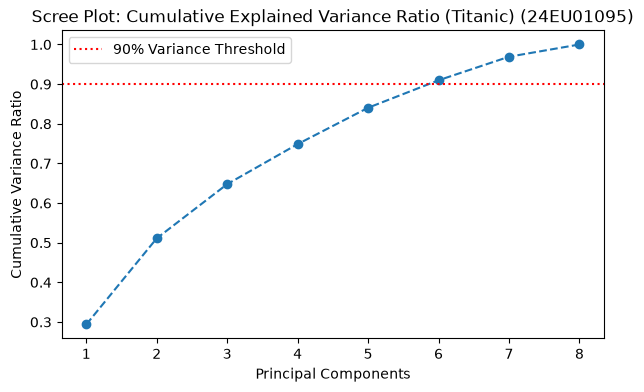

In [6]:
import matplotlib.pyplot as plt

# Fit full PCA to compute complete variance ratios
pca_full_titanic = PCA(random_state=42)
pca_full_titanic.fit(X_titanic_standardized)
cumulative_variance_titanic = np.cumsum(pca_full_titanic.explained_variance_ratio_)

# Plot Cumulative Explained Variance
plt.figure(figsize=(7, 4))
plt.plot(range(1, len(cumulative_variance_titanic) + 1), cumulative_variance_titanic, marker='o', linestyle='--')
plt.axhline(y=0.90, color='r', linestyle=':', label='90% Variance Threshold')
plt.title("Scree Plot: Cumulative Explained Variance Ratio (Titanic) (24EU01095)")
plt.xlabel("Principal Components")
plt.ylabel("Cumulative Variance Ratio")
plt.legend()
plt.show()


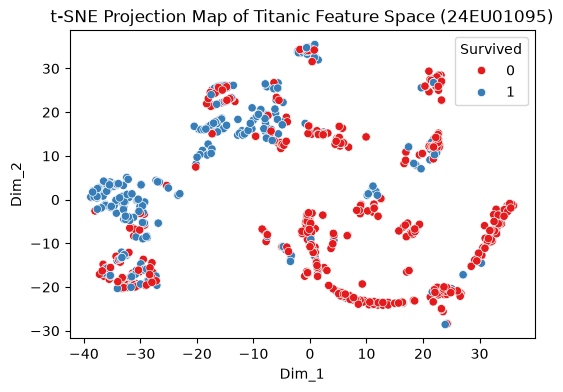

In [7]:
from sklearn.manifold import TSNE
import seaborn as sns

# Project standardized Titanic features onto a 2D space using t-SNE
tsne_titanic = TSNE(n_components=2, perplexity=30, random_state=42)
X_titanic_tsne = tsne_titanic.fit_transform(X_titanic_standardized)

# Construct visualization DataFrame
titanic_tsne_df = pd.DataFrame(X_titanic_tsne, columns=['Dim_1', 'Dim_2'])
titanic_tsne_df['Survived'] = titanic_df['Survived']

# Plot t-SNE clusters
plt.figure(figsize=(6, 4))
sns.scatterplot(data=titanic_tsne_df, x='Dim_1', y='Dim_2', hue='Survived', palette='Set1')
plt.title("t-SNE Projection Map of Titanic Feature Space (24EU01095)")
plt.show()


In [8]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Evaluate performance on all scaled raw features
X_train_raw_t, X_test_raw_t, y_train_t, y_test_t = train_test_split(
    X_titanic_standardized, titanic_df['Survived'], test_size=0.3, random_state=42)
lr_raw_t = LogisticRegression()
lr_raw_t.fit(X_train_raw_t, y_train_t)
acc_raw_t = accuracy_score(y_test_t, lr_raw_t.predict(X_test_raw_t))

# Evaluate performance on the reduced PCA components
X_train_pca_t, X_test_pca_t, _, _ = train_test_split(
    X_titanic_pca_90, titanic_df['Survived'], test_size=0.3, random_state=42)
lr_pca_t = LogisticRegression()
lr_pca_t.fit(X_train_pca_t, y_train_t)
acc_pca_t = accuracy_score(y_test_t, lr_pca_t.predict(X_test_pca_t))

print(f"Accuracy using all {X_titanic_standardized.shape[1]} scaled features: {acc_raw_t * 100:.2f}%")
print(f"Accuracy using {X_titanic_pca_90.shape[1]} PCA components:  {acc_pca_t * 100:.2f}%")


Accuracy using all 8 scaled features: 82.46%
Accuracy using 6 PCA components:  81.72%


In [9]:
from sklearn.feature_selection import SelectKBest, f_classif

# Rank and select the top 4 features using SelectKBest (ANOVA F-value)
selector_t = SelectKBest(score_func=f_classif, k=4)
selector_t.fit(X_titanic_standardized, titanic_df['Survived'])

# Build a summary DataFrame of feature scores
anova_scores_t = pd.DataFrame(
    {'Feature': titanic_features, 'F-Score': selector_t.scores_}
).sort_values(by='F-Score', ascending=False)
print("ANOVA F-Test Scores:\n", anova_scores_t)


ANOVA F-Test Scores:
     Feature     F-Score
1       Sex  372.405724
0    Pclass  115.031272
7  HasCabin   99.253142
5      Fare   63.030764
6  Embarked   10.259355
4     Parch    5.963464
2       Age    3.761528
3     SibSp    1.110572


In [10]:
from sklearn.feature_selection import RFE
from sklearn.linear_model import LogisticRegression

# Run RFE using Logistic Regression to select the top 4 features
estimator_t = LogisticRegression()
rfe_t = RFE(estimator=estimator_t, n_features_to_select=4)
rfe_t.fit(X_titanic_standardized, titanic_df['Survived'])

# Build selection ranking summary
rfe_support_t = pd.DataFrame(
    {'Feature': titanic_features, 'Selected': rfe_t.support_, 'Ranking': rfe_t.ranking_}
).sort_values(by='Ranking')
print("RFE Selected Features:\n", rfe_support_t)


RFE Selected Features:
     Feature  Selected  Ranking
0    Pclass      True        1
1       Sex      True        1
2       Age      True        1
3     SibSp      True        1
7  HasCabin     False        2
6  Embarked     False        3
4     Parch     False        4
5      Fare     False        5


In [11]:
from sklearn.linear_model import LogisticRegression

# Run Logistic Regression with Lasso (L1) regularization
lasso_t = LogisticRegression(penalty='l1', solver='liblinear', C=0.5, random_state=42)
lasso_t.fit(X_titanic_standardized, titanic_df['Survived'])

# Display feature coefficients (zero-coefficients indicate dropped features)
lasso_coefs_t = pd.DataFrame(
    {'Feature': titanic_features, 'Coefficient': lasso_t.coef_[0]}
).sort_values(by='Coefficient', key=abs, ascending=False)
print("Lasso Regularization Coefficients:\n", lasso_coefs_t)


Lasso Regularization Coefficients:
     Feature  Coefficient
1       Sex     1.269372
0    Pclass    -0.725947
2       Age    -0.487779
3     SibSp    -0.332870
7  HasCabin     0.283335
6  Embarked     0.131829
4     Parch    -0.060042
5      Fare     0.058506


c:\Users\spsri\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\spsri\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1429: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


Random Forest Feature Importances:
     Feature  Importance
1       Sex    0.262453
2       Age    0.256280
5      Fare    0.251974
0    Pclass    0.071732
3     SibSp    0.047467
4     Parch    0.037645
7  HasCabin    0.037090
6  Embarked    0.035358


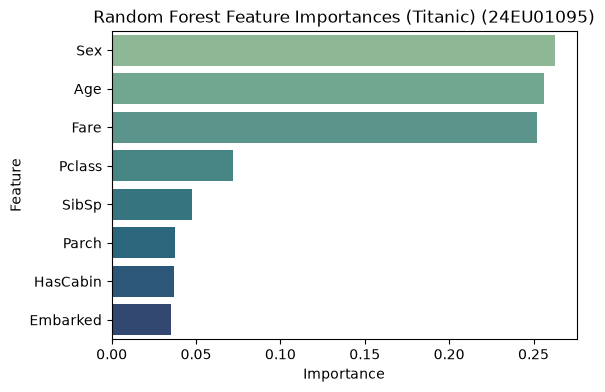

In [12]:
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

# Train Random Forest to compute Gini feature importances
rf_t = RandomForestClassifier(random_state=42)
rf_t.fit(X_titanic, titanic_df['Survived'])  # Random Forest is scale invariant; raw values are suitable

# Plot feature importances
importances_t = pd.DataFrame(
    {'Feature': titanic_features, 'Importance': rf_t.feature_importances_}
).sort_values(by='Importance', ascending=False)
print("Random Forest Feature Importances:\n", importances_t)

plt.figure(figsize=(6, 4))
sns.barplot(data=importances_t, x='Importance', y='Feature', palette='crest')
plt.title("Random Forest Feature Importances (Titanic) (24EU01095)")
plt.show()


In [13]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

# Split dataset into training and test sets
X_train_t, X_test_t, y_train_tp, y_test_tp = train_test_split(
    X_titanic, titanic_df['Survived'], test_size=0.3, random_state=42)

# Model 1: Train on all features
rf_full_t = RandomForestClassifier(random_state=42)
rf_full_t.fit(X_train_t, y_train_tp)
preds_full_t = rf_full_t.predict(X_test_t)

# Model 2: Train on only the top 4 features identified by Random Forest
top_4_cols_t = importances_t.head(4)['Feature'].tolist()
X_train_sub_t = X_train_t[top_4_cols_t]
X_test_sub_t = X_test_t[top_4_cols_t]

rf_sub_t = RandomForestClassifier(random_state=42)
rf_sub_t.fit(X_train_sub_t, y_train_tp)
preds_sub_t = rf_sub_t.predict(X_test_sub_t)

print(f"--- CLASSIFICATION REPORT: ALL FEATURES ({len(titanic_features)} features) ---")
print(classification_report(y_test_tp, preds_full_t))

print("\n--- CLASSIFICATION REPORT: FEATURE-SELECTED SUBSET (Top 4 features) ---")
print(classification_report(y_test_tp, preds_sub_t))


--- CLASSIFICATION REPORT: ALL FEATURES (8 features) ---
              precision    recall  f1-score   support

           0       0.80      0.83      0.82       157
           1       0.75      0.71      0.73       111

    accuracy                           0.78       268
   macro avg       0.78      0.77      0.78       268
weighted avg       0.78      0.78      0.78       268


--- CLASSIFICATION REPORT: FEATURE-SELECTED SUBSET (Top 4 features) ---
              precision    recall  f1-score   support

           0       0.80      0.87      0.83       157
           1       0.79      0.68      0.73       111

    accuracy                           0.79       268
   macro avg       0.79      0.78      0.78       268
weighted avg       0.79      0.79      0.79       268



In [14]:
# Create preprocessed DataFrame combining standardized features and target
processed_titanic_df = pd.DataFrame(data=X_titanic_standardized, columns=titanic_features)
processed_titanic_df['Survived'] = titanic_df['Survived']

# Export to system directory
processed_titanic_df.to_csv("processed_titanic.csv", index=False)
print("Processed Titanic dataset exported successfully to 'processed_titanic.csv'. Shape:", processed_titanic_df.shape)


Processed Titanic dataset exported successfully to 'processed_titanic.csv'. Shape: (891, 9)
